In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [16]:
df = pd.read_csv("/content/loan_data.csv")
df.head()

,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,I need a loan to pay for an international vaca...,26556,581,8314,79.26,employed,Rejected
1,I want to make home improvements like installi...,197392,389,111604,22.14,employed,Rejected
2,"I need a loan for home renovation, including a...",44561,523,34118,45.44,employed,Rejected
3,I need funds to buy new furniture and applianc...,190363,729,118757,10.22,unemployed,Rejected
4,I need a loan to start a small business.,61853,732,19210,44.13,employed,Approved


In [17]:
df=df[['Income','Credit_Score','Loan_Amount','DTI_Ratio','Employment_Status','Approval']]
df.head()

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,26556,581,8314,79.26,employed,Rejected
1,197392,389,111604,22.14,employed,Rejected
2,44561,523,34118,45.44,employed,Rejected
3,190363,729,118757,10.22,unemployed,Rejected
4,61853,732,19210,44.13,employed,Approved


In [18]:
df = df.dropna()
df.tail(5)

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
23995,195242,817,16403,24.32,employed,Approved
23996,150246,729,101572,9.97,employed,Rejected
23997,64571,650,30533,57.35,employed,Rejected
23998,115825,418,89837,10.37,unemployed,Rejected
23999,180440,769,15259,15.06,employed,Approved


In [19]:
df.fillna(method='ffill',inplace=True)
df.head(5)

/tmp/ipykernel_16572/1839174717.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill',inplace=True)


,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,26556,581,8314,79.26,employed,Rejected
1,197392,389,111604,22.14,employed,Rejected
2,44561,523,34118,45.44,employed,Rejected
3,190363,729,118757,10.22,unemployed,Rejected
4,61853,732,19210,44.13,employed,Approved


In [23]:
# Define features (X) and target (y)
df['Approval'] = df['Approval'].map({'Rejected': 0, 'Approved': 1})
df['Employment_Status'] = df['Employment_Status'].map({'unemployed': 0, 'employed': 1})
X = df[['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio', 'Employment_Status']]
y = df['Approval']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9283333333333333
[[3871  176]
 [ 168  585]]


In [28]:
# Probability of default
df['risk_score'] = model.predict_proba(X)[:,1]

# Categorize risk
def risk_category(score):
    if score > 0.7:
        return "High Risk"
    elif score > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

df['risk_level'] = df['risk_score'].apply(risk_category)
print(df['risk_level'])

0           Low Risk
1           Low Risk
2           Low Risk
3           Low Risk
4        Medium Risk
            ...     
23995      High Risk
23996    Medium Risk
23997       Low Risk
23998       Low Risk
23999      High Risk
Name: risk_level, Length: 24000, dtype: object


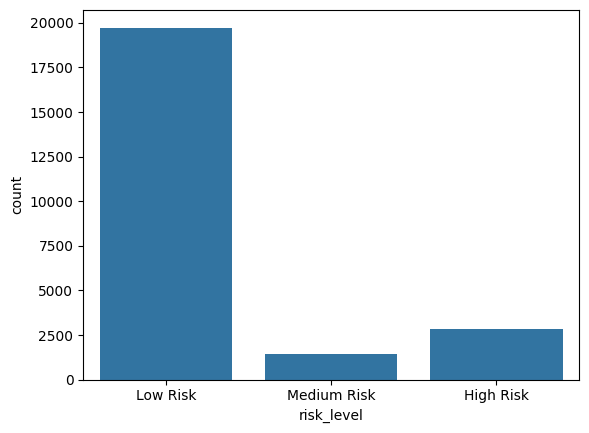

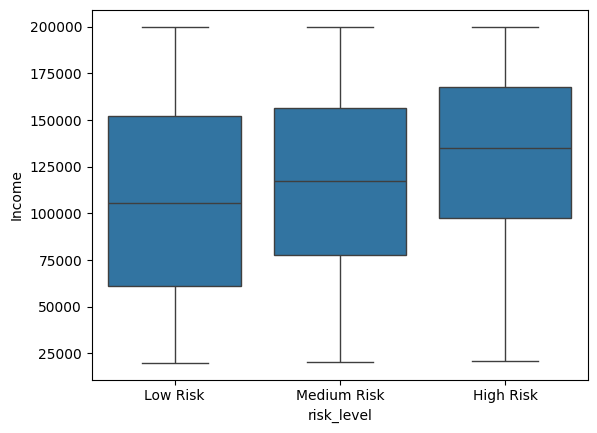

In [30]:
# Risk distribution
sns.countplot(x='risk_level', data=df)
plt.show()

# Income vs Risk
sns.boxplot(x='risk_level', y='Income', data=df)
plt.show()

In [31]:
df.to_csv("processed_loan_data.csv", index=False)